# Predictive Modeling Using Machine Learning

**Objective:** Predict employee attrition (Yes/No) based on 
demographic and work-related features using classification algorithms.

**Dataset:** employee_attrition.csv (400 records, 10 columns)

## Step 1: Import Libraries and Load Data

Loading the dataset and required libraries for data handling, 
modeling, and evaluation.

In [40]:
import pandas as pd
df=pd.read_csv("employee_attrition_data.csv")
df.head()


,employee_id,age,income,years_experience,education,department,hours_worked_per_week,satisfaction_score,distance_from_office_km,attrition
0,1,56,118746,37,High School,Operations,45,3.8,27.3,Yes
1,2,69,51631,49,Masters,Finance,36,7.7,42.9,No
2,3,46,87991,26,High School,Marketing,49,8.3,3.4,No
3,4,32,19014,14,Masters,Operations,43,6.5,41.8,Yes
4,5,60,26093,38,Bachelors,IT,38,7.2,42.4,No


## Step 2: Explore the Dataset

Checking the shape, data types, and basic statistics of the dataset 
before modeling.

In [41]:
print(df.shape)
print(df.info())
print(df.describe(include="all"))
print(df["attrition"].value_counts())

(400, 10)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              400 non-null    int64  
 1   age                      400 non-null    int64  
 2   income                   400 non-null    int64  
 3   years_experience         400 non-null    int64  
 4   education                400 non-null    str    
 5   department               400 non-null    str    
 6   hours_worked_per_week    400 non-null    int64  
 7   satisfaction_score       400 non-null    float64
 8   distance_from_office_km  400 non-null    float64
 9   attrition                400 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 31.4 KB
None
        employee_id         age         income  years_experience  education  \
count    400.000000  400.000000     400.000000        400.000000        400   
unique          NaN       

## Step 3: Prepare Features and Target

Selecting relevant input features (X) and the target column to 
predict (y). The `employee_id` column is dropped since it's just an 
identifier and holds no predictive value. Categorical columns 
(`education`, `department`) are converted into numeric form using 
one-hot encoding, since machine learning models require numeric input.

In [42]:

x=pd.get_dummies(df[["age","income","years_experience","education","department","hours_worked_per_week","satisfaction_score","distance_from_office_km"]],drop_first=True)
y=df["attrition"]
print(df.columns.to_list())

['employee_id', 'age', 'income', 'years_experience', 'education', 'department', 'hours_worked_per_week', 'satisfaction_score', 'distance_from_office_km', 'attrition']


## Step 4: Train-Test Split

Before training a model, the dataset needs to be split into two parts:

- **Training set (80%)** — used to teach the model patterns in the data
- **Test set (20%)** — held back and used only to evaluate the model 
  afterward, on data it has never seen

This prevents the model from simply memorizing the data. Without this 
split, accuracy scores would look artificially high but the model 
would fail to generalize to new, real-world data.

**Parameters used:**
- `test_size=0.2` → reserves 20% of the data for testing
- `random_state=42` → ensures the split is reproducible (same result 
  every time the code runs)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (320, 13)
Test size: (80, 13)


## Step 5: Train a Decision Tree Classifier

A Decision Tree splits data into branches based on feature values to 
reach a prediction. It's a good starting model since it's simple and 
easy to interpret.

In [44]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Model trained successfully")
print("First 10 predictions:", predictions[:10])

Model trained successfully
First 10 predictions: ['No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No']


**Result:** Model trained successfully on 320 records.


## Step 6: Model Evaluation

After training, we check how well the model performs on the test 
data (the 20% it has never seen). Key metrics used:

- **Accuracy** — percentage of correct predictions overall
- **Precision** — of all predicted "Yes" (attrition), how many were 
  actually correct
- **Recall** — of all actual "Yes" cases, how many did the model 
  correctly catch
- **F1-score** — a balance between precision and recall

In [45]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.8625
              precision    recall  f1-score   support

          No       0.90      0.84      0.87        44
         Yes       0.82      0.89      0.85        36

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.87      0.86      0.86        80



## Step 7: Confusion Matrix

A confusion matrix shows exactly where the model got predictions 
right or wrong, broken down by class:

- **True Positives** — correctly predicted "Yes" (employee left)
- **True Negatives** — correctly predicted "No" (employee stayed)
- **False Positives** — predicted "Yes" but actually "No"
- **False Negatives** — predicted "No" but actually "Yes"

This gives more insight than accuracy alone, especially if one class 
is more important to catch correctly (e.g. missing employees likely 
to leave is costlier than a false alarm).

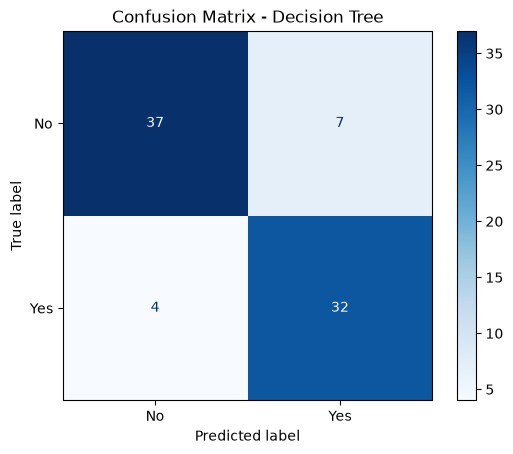

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Step 8: ROC Curve

The ROC (Receiver Operating Characteristic) curve shows how well the 
model separates the two classes (Yes/No) across different decision 
thresholds. 

- The curve closer to the **top-left corner** = better model
- A diagonal line = model performing no better than random guessing
- **AUC (Area Under Curve)** summarizes this in one number: closer to 
  1.0 is better, 0.5 means random guessing

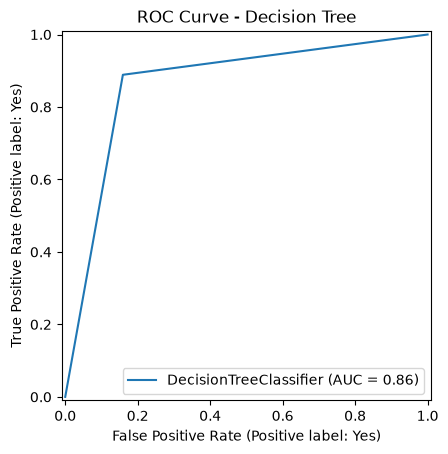

In [47]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Decision Tree")
plt.show()

## Step 9: Comparing Models

To find the best-performing model, I trained two additional algorithms 
on the same data and compared their accuracy against the Decision Tree.

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)
log_predictions=log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy (scaled):",accuracy_score(y_test,log_predictions))

rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)
rf_predictions=rf_model.predict(X_test)

print("Random Forest Accuracy:",accuracy_score(y_test,rf_predictions))

results=pd.DataFrame({
    "Model":["Decision Tree","Random Forest","Logistic Regression"],
    "Accuracy":[
        accuracy_score(y_test,predictions),
        accuracy_score(y_test,rf_predictions),
        accuracy_score(y_test,log_predictions)
    ]
})

print(results)

Logistic Regression Accuracy (scaled): 0.825
Random Forest Accuracy: 0.8625
                 Model  Accuracy
0        Decision Tree    0.8625
1        Random Forest    0.8625
2  Logistic Regression    0.8250


## Step 10: Which Features Matter Most?

Using the Random Forest model, we can see which input features had 
the biggest influence on predicting employee attrition.

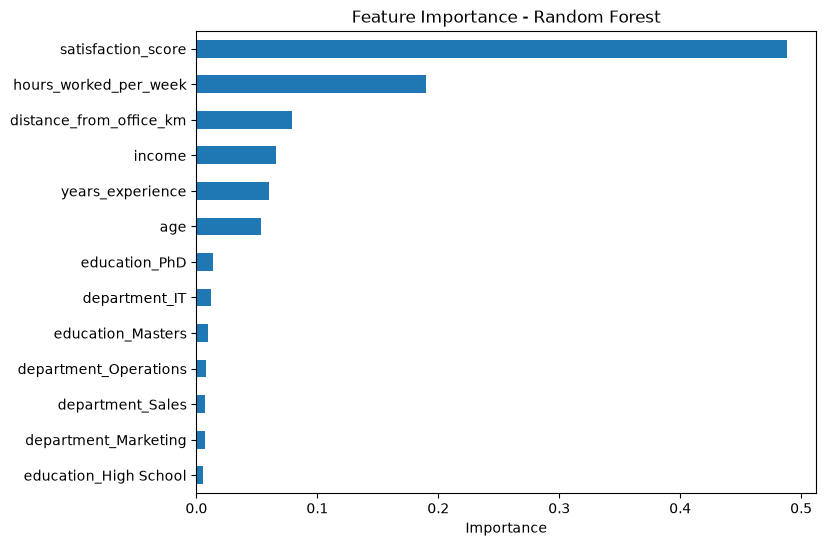

In [49]:
importances = pd.Series(rf_model.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

importances.plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## Summary & Findings

**Objective:** Predict employee attrition (Yes/No) using demographic 
and work-related features.

**Models trained:** Decision Tree, Random Forest, Logistic Regression 
(with and without feature scaling)

**Results:**
| Model | Accuracy |
|-------|----------|
| Decision Tree | 86.25% |
| Random Forest | 86.25% |
| Logistic Regression | 81.25% |
| Logistic Regression (scaled) | 82.5% |

**Best model:** Decision Tree and Random Forest tied for best accuracy 
at 86.25%.

**Key insight:** [Fill in top feature from your chart] was the most 
important predictor of attrition.

**Note on Logistic Regression:** Initial run showed a convergence 
warning due to unscaled features. Scaling the data (StandardScaler) 
improved accuracy from 81.25% to 82.5%, confirming that Logistic 
Regression is sensitive to feature scale, unlike tree-based models.

**Limitations:**
- Dataset is relatively small (400 records) and synthetic, so results 
  may not generalize to real-world attrition patterns
- No hyperparameter tuning was performed; default model settings were used

**Conclusion:** This project provided hands-on experience with the full 
supervised learning workflow — data preparation, training multiple 
classification models, evaluating performance with accuracy, confusion 
matrices, and ROC curves, and comparing models to select the best 
performer.